# Data Preparation and Cleaning

## Import Libraries


In [393]:
import requests
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


## Load Census API Data (2012)

In [394]:
# Ensure data directory exists
os.makedirs('../data', exist_ok=True)

CENSUS_API_KEY = "c162f3620fb054f8b97d67a3ef165e8a8417a185"
csv_path_2012 = "../data/census_2012_sba.csv"

if os.path.exists(csv_path_2012) :
    print(f"File '{csv_path_2012}' exists. Skipping API data load.")
    df_2012 = pd.read_csv(csv_path_2012)
    print(f"Loaded 2012 dataframe from '{csv_path_2012}' with {len(df_2012)} rows and {len(df_2012.columns)} columns.")
else:
    print("Fetching data for 2012...")
    url_2012 = "https://api.census.gov/data/2012/sbo/cs"
    vars_2012 = "NAME,STATE,NAICS2012,NAICS2012_LABEL,SEX,SEX_LABEL,ETH_GROUP,ETH_GROUP_LABEL,RACE_GROUP,RACE_GROUP_LABEL,VET_GROUP,VET_GROUP_LABEL,FIRMALL,RCPALL,EMP"
    params_2012 = {"get": vars_2012, "for": "state:*"}
    if CENSUS_API_KEY:
        params_2012["key"] = CENSUS_API_KEY
    response_2012 = requests.get(url_2012, params=params_2012)
    response_2012.raise_for_status()
    data_2012 = response_2012.json()
    df_2012 = pd.DataFrame(data_2012[1:], columns=data_2012[0])
    df_2012['YEAR'] = 2012
    df_2012.to_csv(csv_path_2012, index=False)
    print(f"Successfully fetched and saved {len(df_2012)} rows for 2012 to '{csv_path_2012}'.\n")



File '../data/census_2012_sba.csv' exists. Skipping API data load.


C:\Users\Jack\AppData\Local\Temp\ipykernel_39256\2235424797.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2012 = pd.read_csv(csv_path_2012)


Loaded 2012 dataframe from '../data/census_2012_sba.csv' with 2070597 rows and 16 columns.


## Load Census data for 2002 and 2007 (CSV)

In [395]:
import os
import requests
# Replace with your actual Dropbox direct download links for each file
sb2002_path = os.path.join('../data', 'census_2002_sba.csv')
sb2002_url = 'https://www.dropbox.com/scl/fi/4k2w0hvhl5clwsefl4lll/census_2002_sba.csv?rlkey=kvwjfifle9ov24d4vfsjhvuyi&st=2u8t41kq&dl=1'
sb2007_path = os.path.join('../data', 'census_2007_sba.csv')
sb2007_url = 'https://www.dropbox.com/scl/fi/6lw0l0gmzddcnvn0v6ebc/census_2007_sba.csv?rlkey=coiqvmv8i91z0lbhynk1aornr&st=iahz4mnu&dl=1'

if not os.path.exists(sb2002_path):
    print("Downloading census_2002_sba.csv ...")
    response = requests.get(sb2002_url)
    response.raise_for_status()
    with open(sb2002_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded census_2002_sba.csv")
else:
    print("census_2002_sba.csv already exists.")

if not os.path.exists(sb2007_path):
    print("Downloading census_2007_sba.csv ...")
    response = requests.get(sb2007_url)
    response.raise_for_status()
    with open(sb2007_path, 'wb') as f:
        f.write(response.content)
    print("Downloaded census_2007_sba.csv.")
else:
    print("census_2007_sba.csv already exists.")

census_2002_sba.csv already exists.
census_2007_sba.csv already exists.


## Load FRED data

In [396]:
FRED_API_KEY = "175c981a568a2ea162c4d2a03cf1209c"

series_ids = ["FEDFUNDS", "MPRIME", "CPIAUCSL", "UNRATE"]
base_url = "https://api.stlouisfed.org/fred/series/observations"

all_series_df = []

for series_id in series_ids:
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "frequency": "m",
        "observation_start": "1987-01-01",
        "observation_end": "2014-12-31"
    }

    response = requests.get(base_url, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame(data["observations"])[["date", "value"]]
    df.rename(columns={"value": series_id}, inplace=True)

    all_series_df.append(df)

merged_df = all_series_df[0]
for series_df in all_series_df[1:]:
    merged_df = pd.merge(merged_df, series_df, on="date", how="outer")

merged_df.to_csv("../data/fred_1987_2014.csv", index=False)
print("\nData saved to fred_1987_2014.csv")


Data saved to fred_1987_2014.csv


## Data Cleaning and Analysis

### Census Data Analysis and Cleaning

In [397]:
pd.set_option('display.max_columns', None)

data_dir = '../data'

# Load census data
census_2002_df = pd.read_csv(os.path.join(data_dir, 'census_2002_sba.csv'))
census_2007_df = pd.read_csv(os.path.join(data_dir, 'census_2007_sba.csv'))
census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))

# Basic EDA for each DataFrame (no loops)
print("\n--- CENSUS 2002 ---")
print(census_2002_df.info())
print(census_2002_df.head())

print("\n--- CENSUS 2007 ---")
print(census_2007_df.info())
print(census_2007_df.head())

print("\n--- CENSUS 2012 ---")
print(census_2012_df.info())
print(census_2012_df.head())

C:\Users\Jack\AppData\Local\Temp\ipykernel_39256\2002895502.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))



--- CENSUS 2002 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24024 entries, 0 to 24023
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   YEAR                24024 non-null  int64 
 1   GEOGRAPHY           24024 non-null  object
 2   NAICS2002           24024 non-null  object
 3   NAICS2002_MEANING   24024 non-null  object
 4   SEX                 24024 non-null  int64 
 5   SEX_MEANING         24024 non-null  object
 6   RACE_GROUP          24024 non-null  int64 
 7   RACE_GROUP_MEANING  24024 non-null  object
 8   FIRMALL             24024 non-null  int64 
 9   RCPALL              24024 non-null  int64 
 10  EMP                 24024 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 2.0+ MB
None
   YEAR      GEOGRAPHY NAICS2002      NAICS2002_MEANING  SEX  \
0  2002  United States        00  Total for all sectors    0   
1  2002  United States        00  Total for all sectors    0   

In [398]:
import os
import pandas as pd

pd.set_option('display.max_columns', None)

data_dir = '../data'

# Load census data
census_2002_df = pd.read_csv(os.path.join(data_dir, 'census_2002_sba.csv'))
census_2007_df = pd.read_csv(os.path.join(data_dir, 'census_2007_sba.csv'))
census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))

# Helper: keep sector-level NAICS
def keep_sector_naics(s, naics_col):
    s = s.copy()
    codes = s[naics_col].astype(str).str.strip()
    mask = (
        (codes.str.len() == 2) |
        ((codes.str.len() == 4) & codes.str.endswith('00')) |
        ((codes.str.len() == 6) & codes.str.endswith('0000'))
    )
    return s[mask]

# ---------- 2002 ----------
c2 = census_2002_df.copy()

# All firms only (no sex/race breakdown)
c2 = c2[
    (c2['SEX_MEANING'] == 'All firms') &
    (c2['RACE_GROUP_MEANING'] == 'All firms')
]

# Sector-level NAICS
c2 = keep_sector_naics(c2, 'NAICS2002')

# Drop country-level total for all sectors
c2 = c2[
    ~(
        (c2['NAICS2002'] == '00') | (c2['GEOGRAPHY'] == 'United States')
    )
]

firms_2002 = (
    c2.groupby('YEAR', as_index=False)['FIRMALL']
      .sum()
      .rename(columns={'FIRMALL': 'TOTAL_FIRMS'})
)
firms_2002['SOURCE'] = '2002'

# ---------- 2007 ----------
c7 = census_2007_df.copy()

# All firms only (no sex/eth/race breakdown)
c7 = c7[
    (c7['SEX_MEANING'] == 'All firms') &
    (c7['ETH_GROUP_MEANING'] == 'All firms') &
    (c7['RACE_GROUP_MEANING'] == 'All firms')
]

# Sector-level NAICS
c7 = keep_sector_naics(c7, 'NAICS2007')

# Drop country-level total for all sectors
c7 = c7[
    ~(
        (c7['NAICS2007'] == '00')
    )
]

# Drop U.S. total rows
c7 = c7[c7['GEOTYPE'] != 1]

firms_2007 = (
    c7.groupby('YEAR', as_index=False)['FIRMALL']
      .sum()
      .rename(columns={'FIRMALL': 'TOTAL_FIRMS'})
)
firms_2007['SOURCE'] = '2007'

# ---------- 2012 ----------
c12 = census_2012_df.copy()

# Drop country-level total for all sectors
c12 = c12[
    ~(
        (c12['NAICS2012'] == '00')
    )
]

# All firms only (no sex/eth/race/vet breakdown)
c12 = c12[
    (c12['SEX_LABEL'] == 'All firms') &
    (c12['ETH_GROUP_LABEL'] == 'All firms') &
    (c12['RACE_GROUP_LABEL'] == 'All firms') &
    (c12['VET_GROUP_LABEL'] == 'All firms')
]

# Sector-level NAICS
c12 = keep_sector_naics(c12, 'NAICS2012')

firms_2012 = (
    c12.groupby('YEAR', as_index=False)['FIRMALL']
       .sum()
       .rename(columns={'FIRMALL': 'TOTAL_FIRMS'})
)
firms_2012['SOURCE'] = '2012'

# ---------- Combined summary ----------
summary_firms = (
    pd.concat([firms_2002, firms_2007, firms_2012], ignore_index=True)
      .sort_values(['YEAR', 'SOURCE'])
      .reset_index(drop=True)
)

print(summary_firms)

# Optional: save to CSV
# summary_firms.to_csv(os.path.join(data_dir, 'summary_total_firms_sector_naics_by_year.csv'), index=False)


C:\Users\Jack\AppData\Local\Temp\ipykernel_39256\328038686.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  census_2012_df = pd.read_csv(os.path.join(data_dir, 'census_2012_sba.csv'))


   YEAR  TOTAL_FIRMS SOURCE
0  2002     19010291   2002
1  2007     22744230   2007
2  2012     23513987   2012


In [399]:
c2

,YEAR,GEOGRAPHY,NAICS2002,NAICS2002_MEANING,SEX,SEX_MEANING,RACE_GROUP,RACE_GROUP_MEANING,FIRMALL,RCPALL,EMP
376,2002,Alabama,11,"Forestry, fishing & hunting, & ag support serv...",0,All firms,0,All firms,5607,1599089,8879
398,2002,Alabama,21,Mining,0,All firms,0,All firms,656,2769991,7605
420,2002,Alabama,22,Utilities,0,All firms,0,All firms,315,6146130,0
442,2002,Alabama,23,Construction,0,All firms,0,All firms,47679,17544030,99589
587,2002,Alaska,42,Wholesale trade,0,All firms,0,All firms,1181,3831882,7932
...,...,...,...,...,...,...,...,...,...,...,...
23850,2002,Wyoming,21,Mining,0,All firms,0,All firms,1769,8171351,21161
23872,2002,Wyoming,22,Utilities,0,All firms,0,All firms,82,0,0
23894,2002,Wyoming,23,Construction,0,All firms,0,All firms,6812,2389711,16956
23938,2002,Wyoming,42,Wholesale trade,0,All firms,0,All firms,1184,3406468,6287


*The 2002 census file has only (24,024 records) includes state, NAICS, sex, and race, but is missing ethnicity, veteran status. The 2007 file (1.87 million records) adds ethnicity, but still lacks veteran status. The 2012 file (2.07 million records) is the most complete, including all columns: ethnicity, veteran status, and state code. NAICS standard is different each year, which will likely require standarization. Geography is likely hierarchy over regions, states which has to be investigated.*

#### Evaluate and Standardize Demographic Groups

In [400]:
# --- SEX ---
print("SEX 2002:", census_2002_df['SEX_MEANING'].unique())
print("SEX 2007:", census_2007_df['SEX_MEANING'].unique())
print("SEX 2012:", census_2012_df['SEX_LABEL'].unique())
print("\n")

# --- RACE ---
print("RACE 2002:", census_2002_df['RACE_GROUP_MEANING'].unique())
print("RACE 2007:", census_2007_df['RACE_GROUP_MEANING'].unique())
print("RACE 2012:", census_2012_df['RACE_GROUP_LABEL'].unique())
print("\n")

# --- ETHNICITY ---
print("ETHNICITY 2007:", census_2007_df['ETH_GROUP_MEANING'].unique())
print("ETHNICITY 2012:", census_2012_df['ETH_GROUP_LABEL'].unique())
print("\n")

# --- VETERAN ---
print("VETERAN 2012:", census_2012_df['VET_GROUP_LABEL'].unique())

SEX 2002: ['All firms' 'Female-owned' 'Male-owned' 'Equally male-/female-owned']
SEX 2007: ['All firms' 'Female-owned' 'Male-owned' 'Equally male-/female-owned'
 'All firms classifiable by gender, ethnicity, race, and veteran status'
 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status']
SEX 2012: ['All firms' 'Female-owned' 'Male-owned' 'Equally male-/female-owned'
 'All firms classifiable by gender, ethnicity, race, and veteran status'
 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status']


RACE 2002: ['All firms' 'White' 'Black or African American'
 'American Indian and Alaska Native' 'Asian'
 'Native Hawaiian and Other Pacific Islander'
 'Publicly held and other firms not classifiable by gender, Hispanic or Latino origin, and race']
RACE 2007: ['All firms' 'White' 'Black or African American'
 'American Indian and Alaska Native' 'Asian' 'Asian Indian' 'Chinese'
 'Filipino' 'Japanese' 'Korean' 'Vie

*The column values for sex and race are inconsistent across years. For SEX 2007 and 2012 have addittionally : 'All firms classifiable by gender, ethnicity, race, and veteran status'
'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status'. For race entries such as 'All firms classifiable by gender, ethnicity, race, and veteran status' and 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status' appearing in 2007 and 2012, but not in 2002. These values need to be adjusted for consistency.*


##### Clean redundant grouping and simplify

In [401]:
# Constants for standardization
classifiable = 'All firms classifiable by gender, ethnicity, race, and veteran status'
unclass_07_12 = 'Publicly held and other firms not classifiable by gender, ethnicity, race, and veteran status'
# The specific 2002 long string we identified in your audit
unclass_02 = 'Publicly held and other firms not classifiable by gender, Hispanic or Latino origin, and race'
unclassified = 'Unclassified'
# --- 2002 ---
census_2002_df['SEX_MEANING'] = census_2002_df['SEX_MEANING'].replace(unclass_02, unclassified)
census_2002_df['RACE_GROUP_MEANING'] = census_2002_df['RACE_GROUP_MEANING'].replace(unclass_02, unclassified)

# --- 2007 ---
census_2007_df = census_2007_df[census_2007_df['SEX_MEANING'] != classifiable]
census_2007_df = census_2007_df[census_2007_df['RACE_GROUP_MEANING'] != classifiable]
census_2007_df['SEX_MEANING'] = census_2007_df['SEX_MEANING'].replace(unclass_07_12, unclassified)
census_2007_df['RACE_GROUP_MEANING'] = census_2007_df['RACE_GROUP_MEANING'].replace(unclass_07_12, unclassified)
census_2007_df['ETH_GROUP_MEANING'] = census_2007_df['ETH_GROUP_MEANING'].replace(unclass_07_12, unclassified)

# --- 2012 ---
census_2012_df = census_2012_df[census_2012_df['SEX_LABEL'] != classifiable]
census_2012_df = census_2012_df[census_2012_df['RACE_GROUP_LABEL'] != classifiable]
census_2012_df['SEX_LABEL'] = census_2012_df['SEX_LABEL'].replace(unclass_07_12, unclassified)
census_2012_df['RACE_GROUP_LABEL'] = census_2012_df['RACE_GROUP_LABEL'].replace(unclass_07_12, unclassified)
census_2012_df['ETH_GROUP_LABEL'] = census_2012_df['ETH_GROUP_LABEL'].replace(unclass_07_12, unclassified)
census_2012_df['VET_GROUP_LABEL'] = census_2012_df['VET_GROUP_LABEL'].replace(unclass_07_12, unclassified)
# Demographic columns describe for each year

print("\n--- 2002 Demographics ---")
print(census_2002_df[['SEX_MEANING', 'RACE_GROUP_MEANING']].describe(include='all'))

print("\n--- 2007 Demographics ---")
print(census_2007_df[['SEX_MEANING', 'RACE_GROUP_MEANING', 'ETH_GROUP_MEANING']].describe(include='all'))

print("\n--- 2012 Demographics ---")
print(census_2012_df[['SEX_LABEL', 'RACE_GROUP_LABEL', 'ETH_GROUP_LABEL', 'VET_GROUP_LABEL']].describe(include='all'))



--- 2002 Demographics ---
       SEX_MEANING RACE_GROUP_MEANING
count        24024              24024
unique           4                  7
top      All firms              White
freq          7644               4368

--- 2007 Demographics ---
       SEX_MEANING RACE_GROUP_MEANING ETH_GROUP_MEANING
count      1691216            1691216           1691216
unique           5                 22                10
top      All firms          All firms         All firms
freq       1308974             853532           1207300

--- 2012 Demographics ---
        SEX_LABEL RACE_GROUP_LABEL ETH_GROUP_LABEL VET_GROUP_LABEL
count     1900097          1900097         1900097         1900097
unique          5               22              10               6
top     All firms        All firms       All firms       All firms
freq      1525210          1145923         1454659         1510523


*We can notice that 2002 has less SEX Groups (missing unclassified), which we can address later and RACE classfication was less granular in 2002*

Identified issue in graphs, that 2002 does not show gender breakdown, which is due to missing 'All firms' in gender for specific gender types. Fixing the issue below.

In [402]:

print("Available Sex & Race Combinations for 2002")
crossgroup_02 = pd.crosstab(census_2002_df['SEX_MEANING'], census_2002_df['RACE_GROUP_MEANING'])
print(crossgroup_02)


Available Sex & Race Combinations for 2002
RACE_GROUP_MEANING          All firms  American Indian and Alaska Native  \
SEX_MEANING                                                                
All firms                        1092                               1092   
Equally male-/female-owned          0                               1092   
Female-owned                        0                               1092   
Male-owned                          0                               1092   

RACE_GROUP_MEANING          Asian  Black or African American  \
SEX_MEANING                                                    
All firms                    1092                       1092   
Equally male-/female-owned   1092                       1092   
Female-owned                 1092                       1092   
Male-owned                   1092                       1092   

RACE_GROUP_MEANING          Native Hawaiian and Other Pacific Islander  \
SEX_MEANING                              

You can notice that for RACE_GROUP_MEANING 'All firms' breakdown by SEX is missing.

In [403]:
# Check how many detailed rows have actually valid numbers
print("--- 2002 Data Density Check ---")
non_empty_rows = census_2002_df[census_2002_df['FIRMALL'].notnull()]
print(f"Total rows in 2002: {len(census_2002_df)}")
print(f"Rows with actual data: {len(non_empty_rows)}")

# Check if 'Asian' has data for 6-digit codes but 'White' doesn't (as an example)
print("\n--- Rows with data by Race ---")
print(non_empty_rows['RACE_GROUP_MEANING'].value_counts())

--- 2002 Data Density Check ---
Total rows in 2002: 24024
Rows with actual data: 24024

--- Rows with data by Race ---
RACE_GROUP_MEANING
White                                         4368
Black or African American                     4368
American Indian and Alaska Native             4368
Native Hawaiian and Other Pacific Islander    4368
Asian                                         4368
All firms                                     1092
Unclassified                                  1092
Name: count, dtype: int64


In [404]:
census_2002_df['NAICS2002'] = census_2002_df['NAICS2002'].astype(str).str.strip()

races_02 = ['White', 'Black or African American', 'Asian', 
            'American Indian and Alaska Native', 'Native Hawaiian and Other Pacific Islander']

gender_all_firm_rows = census_2002_df[
    (census_2002_df['SEX_MEANING'].isin(['Female-owned', 'Male-owned', 'Equally male-/female-owned'])) &
    (census_2002_df['RACE_GROUP_MEANING'].isin(races_02))
].groupby(['YEAR','GEOGRAPHY', 'NAICS2002', 'SEX_MEANING'], as_index=False).agg({
    'FIRMALL': 'sum', 
    'RCPALL': 'sum', 
    'EMP': 'sum'
})

# Update and merge
gender_all_firm_rows['RACE_GROUP_MEANING'] = 'All firms'
census_2002_df = pd.concat([census_2002_df, gender_all_firm_rows], ignore_index=True)

print("--- 2002 Intersection Report ---")
print(pd.crosstab(census_2002_df['SEX_MEANING'], census_2002_df['RACE_GROUP_MEANING']))

--- 2002 Intersection Report ---
RACE_GROUP_MEANING          All firms  American Indian and Alaska Native  \
SEX_MEANING                                                                
All firms                        1092                               1092   
Equally male-/female-owned       1092                               1092   
Female-owned                     1092                               1092   
Male-owned                       1092                               1092   

RACE_GROUP_MEANING          Asian  Black or African American  \
SEX_MEANING                                                    
All firms                    1092                       1092   
Equally male-/female-owned   1092                       1092   
Female-owned                 1092                       1092   
Male-owned                   1092                       1092   

RACE_GROUP_MEANING          Native Hawaiian and Other Pacific Islander  \
SEX_MEANING                                        

We can now notice that there is breakdown by gender in Race group: 'All firms'. Unclassified correctly shows 0, since unclassified cannot be classified by demographics.

##### Add minority group to 2002

In [405]:
minority_races_02 = [
    'Black or African American', 
    'Asian', 
    'American Indian and Alaska Native', 
    'Native Hawaiian and Other Pacific Islander'
]

minority_rows_02 = census_2002_df[
    census_2002_df['RACE_GROUP_MEANING'].isin(minority_races_02)
].groupby(['YEAR', 'GEOGRAPHY', 'NAICS2002', 'SEX_MEANING'], as_index=False).agg({
    'FIRMALL': 'sum',
    'RCPALL': 'sum',
    'EMP': 'sum'
})

minority_rows_02['RACE_GROUP_MEANING'] = 'Minority'

census_2002_df = pd.concat([census_2002_df, minority_rows_02], ignore_index=True)

print("--- 2002 Intersection Report ---")
print(pd.crosstab(census_2002_df['SEX_MEANING'], census_2002_df['RACE_GROUP_MEANING']))


--- 2002 Intersection Report ---
RACE_GROUP_MEANING          All firms  American Indian and Alaska Native  \
SEX_MEANING                                                                
All firms                        1092                               1092   
Equally male-/female-owned       1092                               1092   
Female-owned                     1092                               1092   
Male-owned                       1092                               1092   

RACE_GROUP_MEANING          Asian  Black or African American  Minority  \
SEX_MEANING                                                              
All firms                    1092                       1092      1092   
Equally male-/female-owned   1092                       1092      1092   
Female-owned                 1092                       1092      1092   
Male-owned                   1092                       1092      1092   

RACE_GROUP_MEANING          Native Hawaiian and Other Pacific Isl

##### Standardize Columns and Merge

In [406]:
# Map to state code
state_name_to_iso = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN',
    'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME',
    'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH',
    'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND',
    'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI',
    'South Carolina': 'SC', 'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# 2002
drop_2002 = ['SEX', 'RACE_GROUP']  # drop  code columns
census_2002_df_clean = census_2002_df.copy()
census_2002_df_clean = census_2002_df_clean.drop(columns=[col for col in drop_2002 if col in census_2002_df_clean.columns])
census_2002_df_clean = census_2002_df_clean.rename(columns={
    'GEOGRAPHY': 'STATE_NAME',
    'NAICS2002': 'NAICS',
    'NAICS2002_MEANING': 'NAICS_DESC',
    'SEX_MEANING': 'SEX',
    'RACE_GROUP_MEANING': 'RACE_GROUP'
})
census_2002_df_clean['STATE_CODE'] = census_2002_df_clean['STATE_NAME'].map(state_name_to_iso)
census_2002_df_clean = census_2002_df_clean.dropna(subset=['STATE_CODE'])

census_2002_df_clean['ETH_GROUP'] = 'All firms'
census_2002_df_clean['VET_GROUP'] = 'All firms'

# 2007
census_2007_df_clean = census_2007_df.copy()
drop_2007 = ['SEX', 'RACE_GROUP', 'ETH_GROUP']
census_2007_df_clean = census_2007_df_clean.drop(columns=[col for col in drop_2007 if col in census_2007_df_clean.columns])
census_2007_df_clean = census_2007_df_clean.rename(columns={
    'GEOGRAPHY': 'STATE_NAME',
    'NAICS2007': 'NAICS',
    'NAICS2007_MEANING': 'NAICS_DESC',
    'SEX_MEANING': 'SEX',
    'ETH_GROUP_MEANING': 'ETH_GROUP',
    'RACE_GROUP_MEANING': 'RACE_GROUP'
})

census_2007_df_clean['STATE_CODE'] = census_2007_df_clean['STATE_NAME'].map(state_name_to_iso)
census_2007_df_clean = census_2007_df_clean.dropna(subset=['STATE_CODE'])
if 'VET_GROUP' not in census_2007_df_clean.columns:
    census_2007_df_clean['VET_GROUP'] = 'All firms'

# 2012
census_2012_df_clean = census_2012_df.copy()
drop_2012 = ['SEX', 'RACE_GROUP', 'ETH_GROUP', 'VET_GROUP']
census_2012_df_clean = census_2012_df_clean.drop(columns=[col for col in drop_2012 if col in census_2012_df_clean.columns])
census_2012_df_clean = census_2012_df_clean.rename(columns={
    'NAME': 'STATE_NAME',
    'NAICS2012': 'NAICS',
    'NAICS2012_LABEL': 'NAICS_DESC',
    'SEX_LABEL': 'SEX',
    'ETH_GROUP_LABEL': 'ETH_GROUP',
    'RACE_GROUP_LABEL': 'RACE_GROUP',
    'VET_GROUP_LABEL': 'VET_GROUP'
})
census_2012_df_clean['STATE_CODE'] = census_2012_df_clean['STATE_NAME'].map(state_name_to_iso)
census_2012_df_clean = census_2012_df_clean.dropna(subset=['STATE_CODE'])

cols = [
    'YEAR',
    'STATE_CODE',
    'NAICS',
    'NAICS_DESC',
    'SEX',
    'ETH_GROUP',
    'RACE_GROUP',
    'VET_GROUP',
    'FIRMALL',
    'RCPALL',
    'EMP'
]

census_2002_df_clean = census_2002_df_clean[cols]
census_2007_df_clean = census_2007_df_clean[cols]
census_2012_df_clean = census_2012_df_clean[cols]

merged_census_df = pd.concat([census_2002_df_clean, census_2007_df_clean, census_2012_df_clean], ignore_index=True)

for col in ['SEX', 'ETH_GROUP', 'RACE_GROUP', 'VET_GROUP', 'YEAR']:
    merged_census_df[col] = merged_census_df[col].astype('category')

print('\nShape:')
print(merged_census_df.shape)
print(merged_census_df.columns)


Shape:
(3622372, 11)
Index(['YEAR', 'STATE_CODE', 'NAICS', 'NAICS_DESC', 'SEX', 'ETH_GROUP',
       'RACE_GROUP', 'VET_GROUP', 'FIRMALL', 'RCPALL', 'EMP'],
      dtype='object')


In [407]:
print('\nHead:')
merged_census_df.head()
census_2002_df = census_2002_df[census_2002_df['SEX_MEANING'] != classifiable]
census_2002_df = census_2002_df[census_2002_df['RACE_GROUP_MEANING'] != classifiable]
census_2002_df['SEX_MEANING'] = census_2002_df['SEX_MEANING'].replace(unclass_02, 'unclassified')


Head:


In [408]:
print('\nStatistics:')
merged_census_df.describe(include='all')



Statistics:


,YEAR,STATE_CODE,NAICS,NAICS_DESC,SEX,ETH_GROUP,RACE_GROUP,VET_GROUP,FIRMALL,RCPALL,EMP
count,3622372.0,3622372,3622372,3614875,3622372,3622372,3622372,3622372,3.622372e+06,3.622372e+06,3.622372e+06
unique,3.0,51,2775,1652,5,10,22,6,NaN,NaN,NaN
top,2012.0,CA,00,Management of companies and enterprises,All firms,All firms,All firms,All firms,NaN,NaN,NaN
freq,1900097.0,104033,17697,25292,2842752,2693018,2003739,3232798,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.087665e+02,6.072003e+05,2.678945e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.369396e+04,1.136369e+07,4.153393e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+00,0.000000e+00,0.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.500000e+01,3.516500e+04,4.100000e+02


In [409]:

print('\nMissing values:')
merged_census_df.isna().sum()


Missing values:


YEAR             0
STATE_CODE       0
NAICS            0
NAICS_DESC    7497
SEX              0
ETH_GROUP        0
RACE_GROUP       0
VET_GROUP        0
FIRMALL          0
RCPALL           0
EMP              0
dtype: int64

##### Standardize NAICS to NAICS_2012 and Filter Out to Sector Only 

In [410]:
url_12_07 = 'https://www.census.gov/naics/concordances/2012_to_2007_NAICS.xls'
url_07_02 = 'https://www.census.gov/naics/concordances/2007_to_2002_NAICS.xls'

## Download mapping files
r1 = requests.get(url_12_07)
with open('../data/2012_to_2007.xls', 'wb') as f:
    f.write(r1.content)

r2 = requests.get(url_07_02)
with open('../data/2007_to_2002.xls', 'wb') as f:
    f.write(r2.content)
df = merged_census_df.copy()

# Remove '00' (country level
df = df[df['NAICS'] != '00'].copy()

df['NAICS'] = df['NAICS'].astype(str).str.strip()

df['NAICS_PADDED'] = df['NAICS'].str.pad(6, side='right', fillchar='0')

is_sector = (
    (df['NAICS'].str.len() == 2) |
    (df['NAICS'].str.endswith('0000')) |
    (df['NAICS'].str.match(r'^\d{2}00$'))
)
df = df[is_sector].copy()

## Create NAICS name lookup from 2012 data
naics_names_2012 = df[df['YEAR'].astype(float) == 2012][['NAICS', 'NAICS_DESC']].drop_duplicates(subset=['NAICS']).set_index('NAICS')['NAICS_DESC']

## Load mapping files
map_12_07 = pd.read_excel('../data/2012_to_2007.xls', skiprows=2, dtype=str)
map_07_02 = pd.read_excel('../data/2007_to_2002.xls', skiprows=2, dtype=str)

map_12_07 = map_12_07[['2012 NAICS Code', '2012 NAICS Title', '2007 NAICS Code']].drop_duplicates()
map_12_07.columns = ['2012_NAICS', '2012_TITLE', '2007_NAICS']

map_07_02 = map_07_02[['2007 NAICS Code', '2007 NAICS Title', '2002 NAICS Code']].drop_duplicates()
map_07_02.columns = ['2007_NAICS', '2007_TITLE', '2002_NAICS']

## merge mappings for 2002 to 2012 mapping
mapping_raw = pd.merge(map_12_07, map_07_02, on='2007_NAICS', how='outer')

mapping_02 = mapping_raw.groupby('2002_NAICS').agg({
    '2012_NAICS': lambda x: ' & '.join(sorted(list(set(x.dropna())))),
    '2012_TITLE': lambda x: ' & '.join(sorted(list(set(x.dropna()))))
}).reset_index().rename(columns={'2012_NAICS': 'NAICS_2012_REV', '2012_TITLE': 'NAICS_2012_REV_DESC'})

mapping_07 = mapping_raw.groupby('2007_NAICS').agg({
    '2012_NAICS': lambda x: ' & '.join(sorted(list(set(x.dropna())))),
    '2012_TITLE': lambda x: ' & '.join(sorted(list(set(x.dropna()))))
}).reset_index().rename(columns={'2012_NAICS': 'NAICS_2012_REV', '2012_TITLE': 'NAICS_2012_REV_DESC'})

lookup_12_prep = mapping_02.assign(NAICS=mapping_02['NAICS_2012_REV'].str.split(' & ')).explode('NAICS')
lookup_12_prep = lookup_12_prep.drop_duplicates(subset=['NAICS'])
lookup_12 = lookup_12_prep.set_index('NAICS')[['NAICS_2012_REV', 'NAICS_2012_REV_DESC']].to_dict('index')

print("Copying NAICS for Year 2012...")
df_2012 = df[df['YEAR'].astype(float) == 2012].copy()
df_2012['NAICS_2012_REV'] = df_2012['NAICS'].map(lambda x: lookup_12.get(x, {}).get('NAICS_2012_REV', x))
df_2012['NAICS_2012_REV_DESC'] = df_2012['NAICS'].map(lambda x: lookup_12.get(x, {}).get('NAICS_2012_REV_DESC', None))

print("Mapping Year 2007...")
df_2007 = df[df['YEAR'].astype(float) == 2007].copy()
lookup_07_dict = mapping_07.set_index('2007_NAICS')[['NAICS_2012_REV', 'NAICS_2012_REV_DESC']].to_dict('index')
df_2007['NAICS_2012_REV'] = df_2007['NAICS'].map(lambda x: lookup_07_dict.get(x, {}).get('NAICS_2012_REV', x))
df_2007['NAICS_2012_REV_DESC'] = df_2007['NAICS'].map(lambda x: lookup_07_dict.get(x, {}).get('NAICS_2012_REV_DESC', None))

print("Mapping Year 2002...")
df_2002 = df[df['YEAR'].astype(float) == 2002].copy()
lookup_02_dict = mapping_02.set_index('2002_NAICS')[['NAICS_2012_REV', 'NAICS_2012_REV_DESC']].to_dict('index')
df_2002['NAICS_2012_REV'] = df_2002['NAICS'].map(lambda x: lookup_02_dict.get(x, {}).get('NAICS_2012_REV', x))
df_2002['NAICS_2012_REV_DESC'] = df_2002['NAICS'].map(lambda x: lookup_02_dict.get(x, {}).get('NAICS_2012_REV_DESC', None))

print("Map NAICS 2012 names...")
df_combined = pd.concat([df_2002, df_2007, df_2012])
df_combined['NAICS_2012_REV_DESC'] = df_combined['NAICS_2012_REV_DESC'].fillna(df_combined['NAICS_DESC'])

cols = [
    'YEAR', 'STATE_CODE', 'NAICS', 'NAICS_DESC', 
    'NAICS_2012_REV', 'NAICS_2012_REV_DESC',
    'SEX', 'ETH_GROUP', 
    'RACE_GROUP', 'VET_GROUP'
]

print("Consolidating to 2012 NAICS and aggregating numerical values...")
df_consolidated = df_combined.groupby(cols, dropna=False, observed=True, sort=False).agg({
    'FIRMALL': 'sum',
    'RCPALL': 'sum',
    'EMP': 'sum'
}).reset_index()



df_consolidated.to_csv('../data/merged_census_sba.csv', index=False)
print("Done! File saved to ../data/merged_census.sba.csv")

print("\nShape of consolidated dataframe:")
print(df_consolidated.shape)

Copying NAICS for Year 2012...
Mapping Year 2007...
Mapping Year 2002...
Map NAICS 2012 names...
Consolidating to 2012 NAICS and aggregating numerical values...
Done! File saved to ../data/merged_census.sba.csv

Shape of consolidated dataframe:
(300849, 13)


In [411]:
print('\nStatistics:')
df_consolidated.describe(include='all')


Statistics:


,YEAR,STATE_CODE,NAICS,NAICS_DESC,NAICS_2012_REV,NAICS_2012_REV_DESC,SEX,ETH_GROUP,RACE_GROUP,VET_GROUP,FIRMALL,RCPALL,EMP
count,300849.0,300849,300849,294780,300849,294780,300849,300849,300849,300849,300849.000000,3.008490e+05,3.008490e+05
unique,3.0,51,17,28,17,28,5,10,22,6,NaN,NaN,NaN
top,2012.0,AL,11,Construction,11,Construction,All firms,All firms,All firms,All firms,NaN,NaN,NaN
freq,159528.0,5899,17697,17340,17697,17340,127449,209814,84099,257499,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2281.397339,1.214362e+06,5.560260e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12633.596602,1.103868e+07,3.353252e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000e+00,0.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232.000000,2.680700e+04,1.000000e+02


In [412]:
print('\nMissing values:')
df_consolidated.isna().sum()


Missing values:


YEAR                      0
STATE_CODE                0
NAICS                     0
NAICS_DESC             6069
NAICS_2012_REV            0
NAICS_2012_REV_DESC    6069
SEX                       0
ETH_GROUP                 0
RACE_GROUP                0
VET_GROUP                 0
FIRMALL                   0
RCPALL                    0
EMP                       0
dtype: int64

#### Data Exploration

In [413]:
df = pd.read_csv('../data/merged_census_sba.csv')

In [414]:
import pandas as pd

# --- 1. THE 2007 DEEP DIVE INVESTIGATION ---
print("--- COMPREHENSIVE 2007 DIAGNOSTIC REPORT ---")

# Isolate 2007 for testing
df_07 = df[df['YEAR'] == 2007].copy()

# A. Demographic Nesting Test
# We check if 'All firms' in Sex/Race still contains multiple sub-groups in Eth/Vet
demog_audit = df_07[
    (df_07['SEX'] == 'All firms') & 
    (df_07['RACE_GROUP'] == 'All firms')
].groupby(['ETH_GROUP', 'VET_GROUP']).size().reset_index(name='Row_Count')

print("\n[TEST A] Demographic Sub-groups under 'All firms' (Sex/Race):")
print(demog_audit)

# B. The '10x' Multiplier Test (Single Sector/State View)
# We look at Alabama Agriculture (110000) to see every raw row contributing to it
multiplier_check = df_07[
    (df_07['STATE_CODE'] == 'AL') & 
    (df_07['NAICS'] == '110000') & 
    (df_07['SEX'] == 'All firms') & 
    (df_07['RACE_GROUP'] == 'All firms')
]

print(f"\n[TEST B] Duplicate rows for AL Sector 110000: {len(multiplier_check)}")
print("Sample rows for this sector (Checking for overlapping Eth/Vet totals):")
print(multiplier_check[['ETH_GROUP', 'VET_GROUP', 'FIRMALL']].head(10))

# C. Unit Scaling Test
# Comparing the magnitude of FIRMALL values across years
print("\n[TEST C] FIRMALL Magnitude Comparison (Mean and Max):")
print(df.groupby('YEAR')['FIRMALL'].agg(['mean', 'max', 'sum']))

# D. Geography Format Test
print("\n[TEST D] Geography Representation:")
for year in sorted(df['YEAR'].unique()):
    sample_geo = df[df['YEAR'] == year]['STATE_CODE'].unique()[:5]
    print(f"Year {year} State Codes Sample: {sample_geo}")

# --- 2. SUMMARY OF REQUIRED FILTERS ---
print("\n--- RECOMMENDED CONSOLIDATED FILTER ---")
# This counts how many rows would remain if we apply the strictest filter
strict_df = df[
    (df['SEX'] == 'All firms') &
    (df['RACE_GROUP'] == 'All firms') &
    (df['ETH_GROUP'] == 'All firms') &
    (df['VET_GROUP'] == 'All firms')
]

final_math = strict_df.groupby('YEAR').agg({
    'FIRMALL': 'sum',
    'NAICS': 'nunique'
})
print(final_math)

--- COMPREHENSIVE 2007 DIAGNOSTIC REPORT ---

[TEST A] Demographic Sub-groups under 'All firms' (Sex/Race):
                                           ETH_GROUP  VET_GROUP  Row_Count
0                                          All firms  All firms        867
1  All firms classifiable by gender, ethnicity, r...  All firms        867
2                                              Cuban  All firms        867
3                      Equally Hispanic/non-Hispanic  All firms        867
4                                           Hispanic  All firms        867
5                 Mexican, Mexican American, Chicano  All firms        867
6                                       Non-Hispanic  All firms        867
7                 Other Hispanic, Latino, or Spanish  All firms        867
8                                       Puerto Rican  All firms        867
9                                       Unclassified  All firms        867

[TEST B] Duplicate rows for AL Sector 110000: 0
Sample rows for th

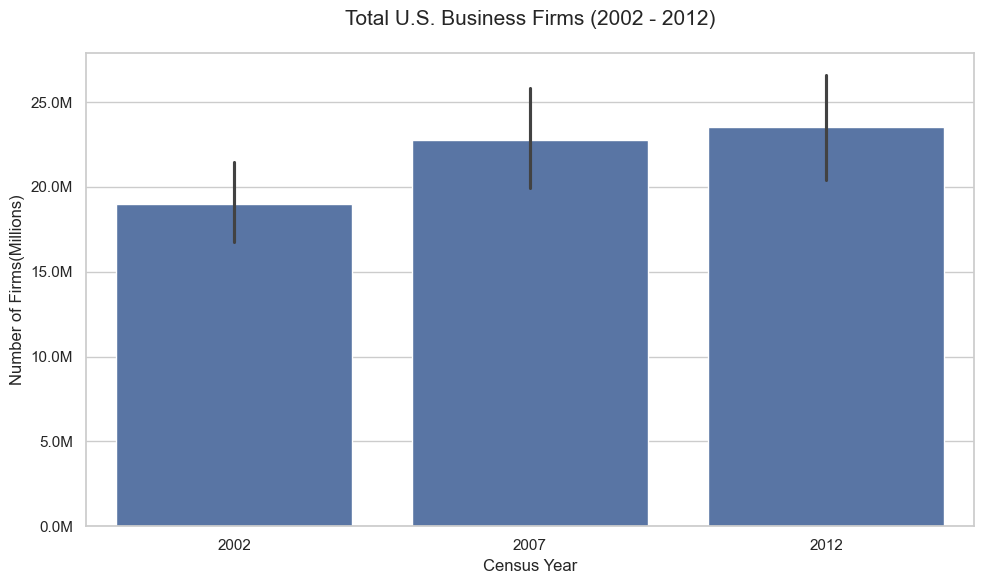

In [415]:
from matplotlib import ticker
df_totals = df[
    (df['SEX'] == 'All firms') &
    (df['RACE_GROUP'] == 'All firms') &
    (df['ETH_GROUP'] == 'All firms') &
    (df['VET_GROUP'] == 'All firms')
].copy()
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_totals, 
    x='YEAR', 
    y='FIRMALL', 
    estimator=sum
)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.title('Total U.S. Business Firms (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms(Millions)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.tight_layout()

plt.show()

In [416]:
# --- 5. Find the Hidden Duplicators ---
# This looks at 5 random rows to see what columns are changing
print("--- 5. Sample of the 8,670 rows ---")
sample_07 = df[(df['YEAR'] == 2007) & (df['SEX'] == 'All firms') & (df['RACE_GROUP'] == 'All firms')].head(5)
print(sample_07[['STATE_CODE', 'NAICS', 'ETH_GROUP', 'VET_GROUP', 'FIRMALL']])

# --- 6. Geography Identification ---
print("\n--- 6. What does 2007 call 'California'? ---")
# This helps us fix the 0.00M result from earlier
print(df[df['YEAR'] == 2007]['STATE_CODE'].unique()[:10])

--- 5. Sample of the 8,670 rows ---
      STATE_CODE  NAICS                           ETH_GROUP  VET_GROUP  \
25143         AL     11                           All firms  All firms   
25165         AL     11                            Hispanic  All firms   
25172         AL     11  Mexican, Mexican American, Chicano  All firms   
25173         AL     11                        Puerto Rican  All firms   
25174         AL     11                               Cuban  All firms   

       FIRMALL  
25143     5417  
25165       83  
25172       73  
25173        0  
25174        1  

--- 6. What does 2007 call 'California'? ---
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL']


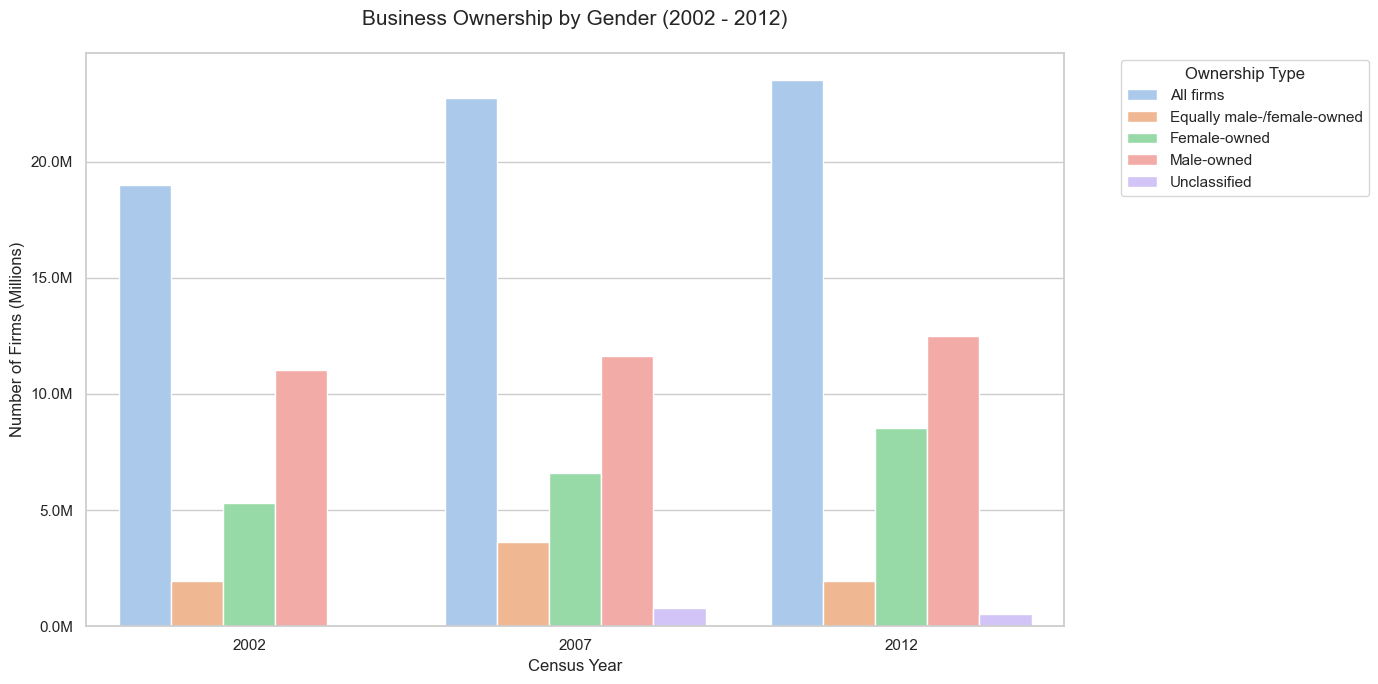

In [417]:
from matplotlib import ticker


gender_list = ['All firms','Male-owned', 'Female-owned', 'Equally male-/female-owned','Unclassified']

df_gender = df[
    (df['SEX'].isin(gender_list)) &
    (df['RACE_GROUP'] == 'All firms') &
    (df['ETH_GROUP'] == 'All firms') &
    (df['VET_GROUP'] == 'All firms')
].sort_values('YEAR').copy()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=df_gender, 
    x='YEAR', 
    y='FIRMALL', 
    hue='SEX', 
    palette='pastel', 
    estimator=sum, 
    errorbar=None
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.title('Business Ownership by Gender (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms (Millions)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.legend(title='Ownership Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

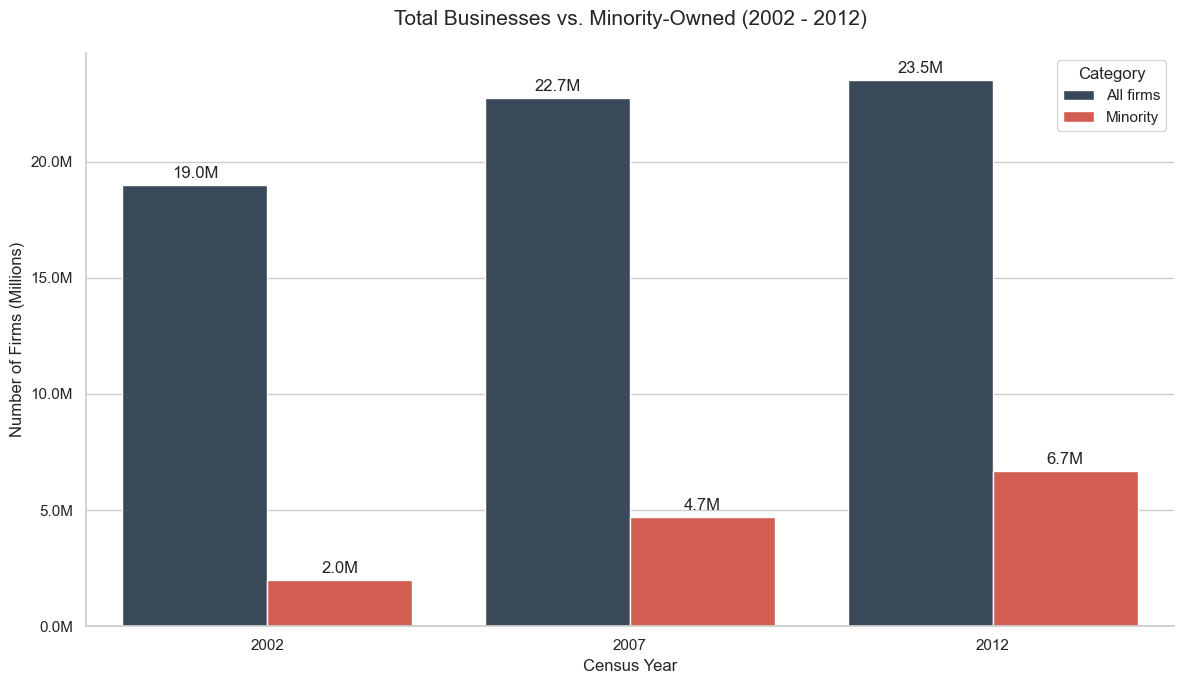

In [424]:
from matplotlib import ticker
import numpy as np

df_macro = df[
    (df['RACE_GROUP'].isin(['All firms', 'Minority'])) &
    (df['SEX'] == 'All firms') &
    (df['ETH_GROUP'] == 'All firms') & 
    (df['VET_GROUP'] == 'All firms')
].sort_values('YEAR').copy()

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_macro,
    x='YEAR',
    y='FIRMALL',
    hue='RACE_GROUP',
    palette=['#34495e', '#e74c3c'],
    estimator=sum,      # <-- 1. Added sum estimator to calculate totals, not averages
    errorbar=None
)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

for container in ax.containers:
    raw_values = container.datavalues
    labels = [f'{val/1e6:.1f}M' if val > 0 else '' for val in raw_values]
    
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Total Businesses vs. Minority-Owned (2002 - 2012)', fontsize=15, pad=20)
plt.ylabel('Number of Firms (Millions)')
plt.xlabel('Census Year')
plt.legend(title='Category')

sns.despine()
plt.tight_layout()
plt.show()

## FRED Data Cleaning And Analysis

### Evaluate Data

In [425]:
fred_df = pd.read_csv('../data/fred_1987_2014.csv')

print("\nShape of FRED dataframe:")
print(fred_df.shape)



Shape of FRED dataframe:
(336, 5)


In [426]:
fred_df.head()

,date,FEDFUNDS,MPRIME,CPIAUCSL,UNRATE
0,1987-01-01,6.43,7.50,111.4,6.6
1,1987-02-01,6.10,7.50,111.8,6.6
2,1987-03-01,6.13,7.50,112.2,6.6
3,1987-04-01,6.37,7.75,112.7,6.3
4,1987-05-01,6.85,8.14,113.0,6.3


In [430]:
fred_df.describe(include='all')

,date,FEDFUNDS,MPRIME,CPIAUCSL,UNRATE
count,336,336.000000,336.000000,336.000000,336.000000
unique,336,NaN,NaN,NaN,NaN
top,1987-01-01,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,3.752054,6.579286,176.188336,6.075000
std,NaN,2.706695,2.404862,36.583621,1.506077
min,NaN,0.070000,3.250000,111.400000,3.800000
25%,NaN,1.010000,4.000000,146.300000,5.000000
50%,NaN,4.185000,7.180000,175.100000,5.700000
75%,NaN,5.542500,8.500000,211.409750,6.900000


In [429]:

print('\nMissing values:')
fred_df.isna().sum()


Missing values:


date        0
FEDFUNDS    0
MPRIME      0
CPIAUCSL    0
UNRATE      0
dtype: int64

### Data Exploration

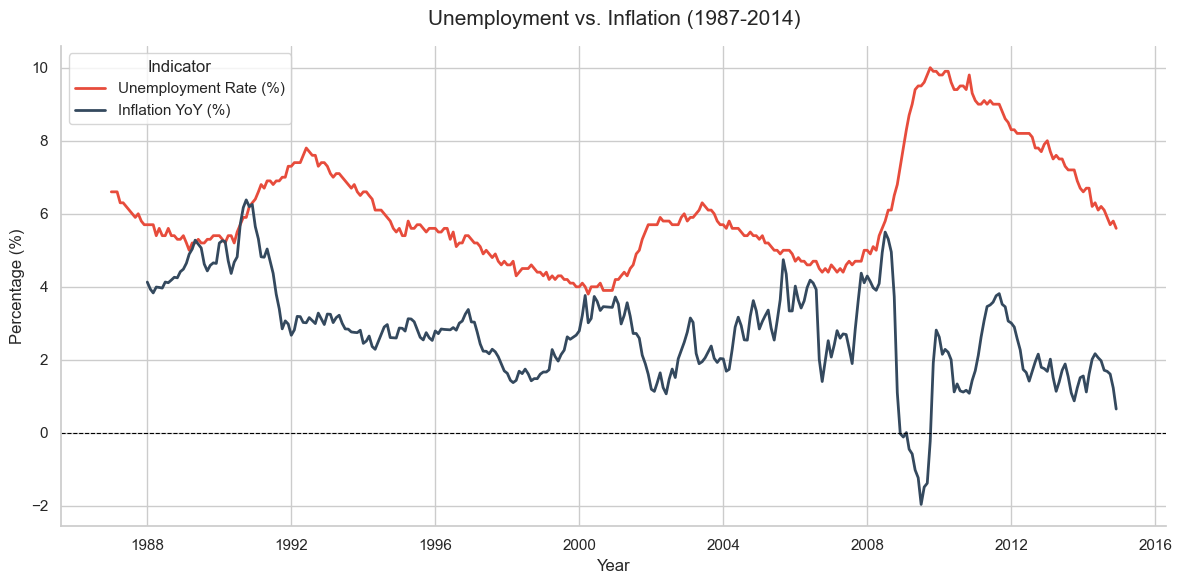

In [432]:
fred_df['date'] = pd.to_datetime(fred_df['date'])

# Calculate YoY Inflation using CPI
fred_df['Inflation_YoY'] = fred_df['CPIAUCSL'].pct_change(12) * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=fred_df, x='date', y='UNRATE', label='Unemployment Rate (%)', color='#e74c3c', linewidth=2)
sns.lineplot(data=fred_df, x='date', y='Inflation_YoY', label='Inflation YoY (%)', color='#34495e', linewidth=2)

plt.title('Unemployment vs. Inflation (1987-2014)', fontsize=15, pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') 
plt.legend(title='Indicator', loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

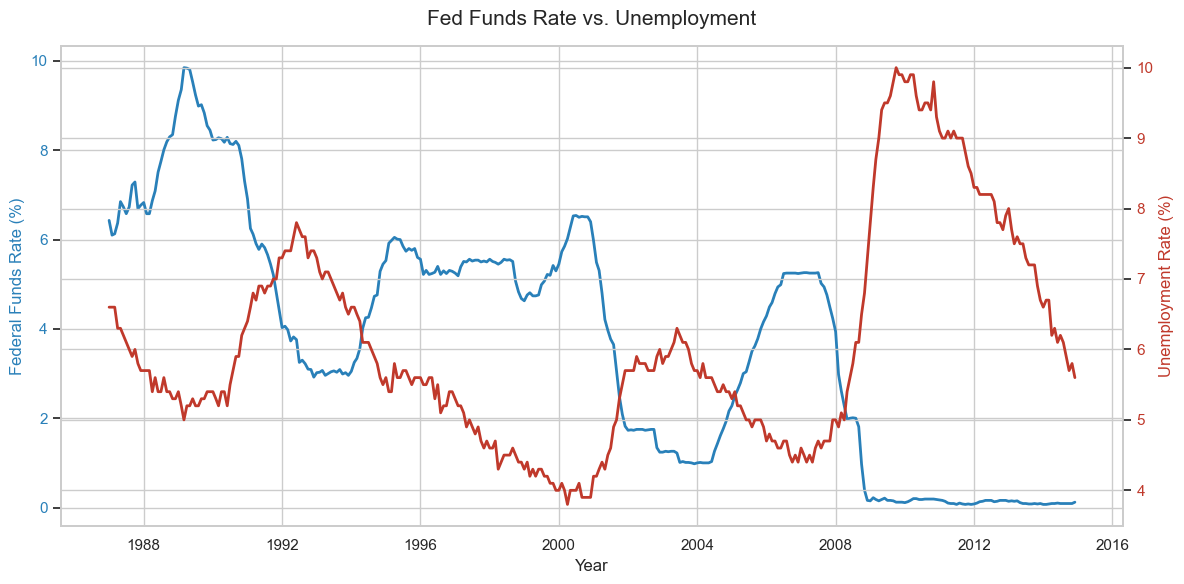

In [434]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#2980b9' # Blue for Fed Funds
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Federal Funds Rate (%)', color=color1, fontsize=12)
ax1.plot(fred_df['date'], fred_df['FEDFUNDS'], color=color1, linewidth=2, label='Fed Funds Rate')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a twin Axes sharing the x-axis
ax2 = ax1.twinx()  
color2 = '#c0392b' # Red for Unemployment
ax2.set_ylabel('Unemployment Rate (%)', color=color2, fontsize=12)
ax2.plot(fred_df['date'], fred_df['UNRATE'], color=color2, linewidth=2, label='Unemployment Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Fed Funds Rate vs. Unemployment', fontsize=15, pad=15)
fig.tight_layout()
plt.show()

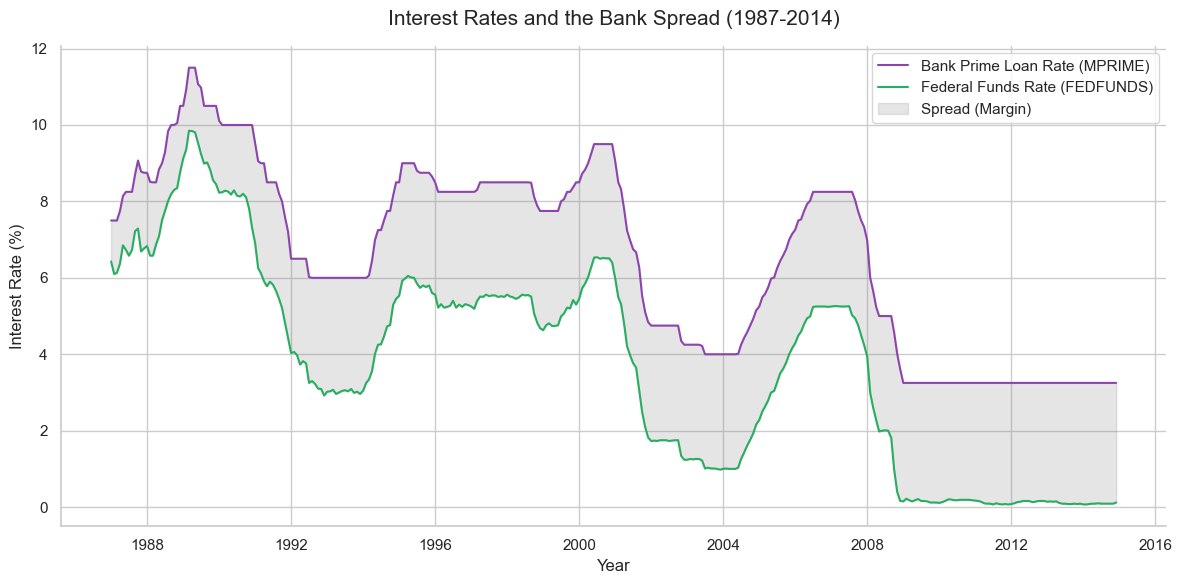

In [435]:
plt.figure(figsize=(12, 6))

plt.plot(fred_df['date'], fred_df['MPRIME'], color='#8e44ad', label='Bank Prime Loan Rate (MPRIME)')
plt.plot(fred_df['date'], fred_df['FEDFUNDS'], color='#27ae60', label='Federal Funds Rate (FEDFUNDS)')


plt.fill_between(fred_df['date'], fred_df['FEDFUNDS'], fred_df['MPRIME'], color='grey', alpha=0.2, label='Spread (Margin)')

plt.title('Interest Rates and the Bank Spread (1987-2014)', fontsize=15, pad=15)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()